# PLEM — Loss Ablation Notebook

**Research question:** does each geometry-aware term in `losses/PLEMMultiTaskLoss` actually encode
the geometric sensitivity it claims to, before we spend a real (CPU-only) training run finding out?

This notebook is the synthetic-only counterpart to `metric_comparison.ipynb`, but for the
**training loss** (`losses/`) instead of the **evaluation metrics** (`metrics/`). It imports the
sweep functions from `tests/test_loss_sensitivity.py` (same synthetic scenes/perturbation families
as `tests/test_sensitivity.py`) and renders the same kind of small-multiples charts + colour-coded
summary table the eval-metric notebooks already use.

Each sweep degrades a synthetic *prediction* relative to a fixed ground truth and reports, per
degradation severity, **loss value** (not accuracy) under five configurations built from
`PLEMMultiTaskLoss`'s own sub-term breakdown:

- `ce_dice_only` — the base term alone (no geometric awareness)
- `plus_tolerance` — + `ToleranceBandLoss` (DTAF1 analog)
- `plus_cldice` — + `SoftClDiceLoss` (clDice analog)
- `plus_heatmap` — + `PointHeatmapLoss` (point-F1 analog)
- `full` — all four terms combined

Expected story (see `CLAUDE.md`): `plus_cldice` should rise sharply under road width/offset
perturbation where `ce_dice_only` stays comparatively flat; `plus_heatmap` should be the term most
distinctly shape-sensitive to point jitter/dropout/clutter, and should stay flat (negative control)
under road/building-only perturbations that don't touch the point class. A flat curve where
sensitivity is expected is a signal the loss math is wrong, not a finding to report as-is — this
notebook exists to catch that before it's baked into a real training run.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'tests'))

import matplotlib.pyplot as plt
import pandas as pd

from test_loss_sensitivity import (
    sweep_road_offset_loss, sweep_road_breakage_loss, sweep_road_thickness_loss,
    sweep_building_erosion_loss, sweep_point_jitter_loss, sweep_point_dropout_loss,
    sweep_point_clutter_loss, CONFIG_KEYS, RAW_KEYS, _RAW_COLORS, _RAW_TITLES,
)

%matplotlib inline

## 1. Road / building sweeps — tolerance & clDice ablation

`plus_tolerance`'s own value should stay low within DTAF1's 10px road tolerance / 2px building
tolerance and grow beyond it. `plus_cldice`'s own value should stay comparatively low across a wide
range of road *thickness* (its documented, `iters`-bounded width-invariance — see
`losses/cldice.py`), while `ce_dice_only`'s plain-Dice component is width-sensitive throughout.
Each subplot below is a different term's own raw value on its own y-scale (the four terms differ by
orders of magnitude, so a shared axis would flatten the non-dominant ones to invisibility — see
`tests/test_loss_sensitivity.py::_plot_sweep`'s docstring).

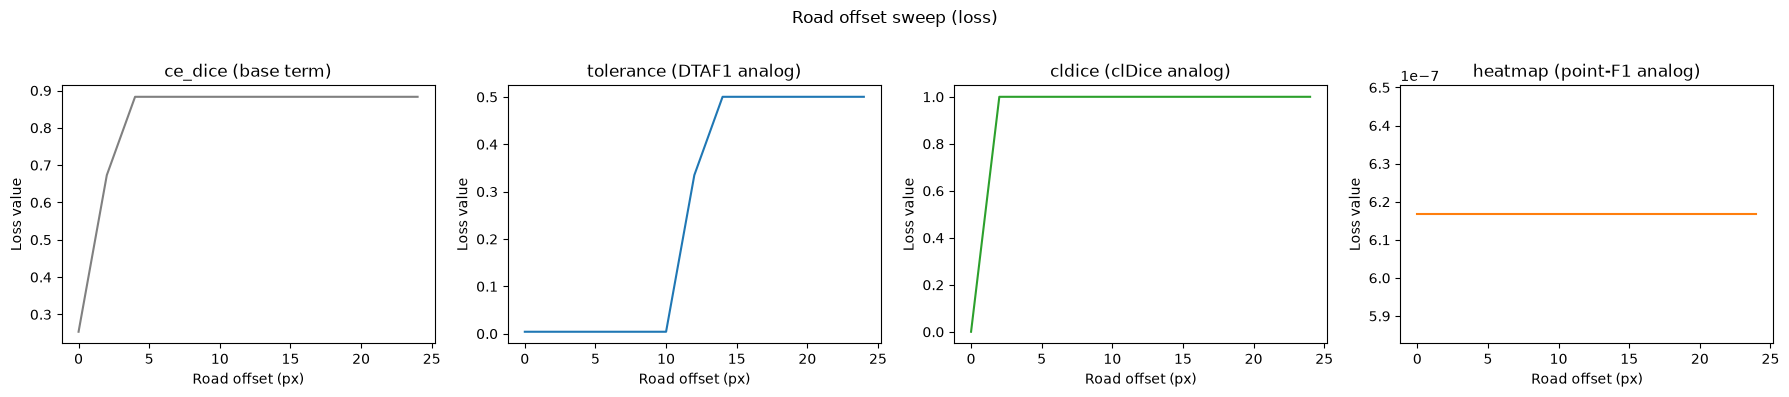

In [2]:
def plot_small_multiples(results, x_key, xlabel, title):
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for ax, k in zip(axes, RAW_KEYS):
        ax.plot(results[x_key], results[k], '-', color=_RAW_COLORS[k])
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Loss value')
        ax.set_title(_RAW_TITLES[k])
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

r_offset = sweep_road_offset_loss()
plot_small_multiples(r_offset, 'offset', 'Road offset (px)', 'Road offset sweep (loss)')

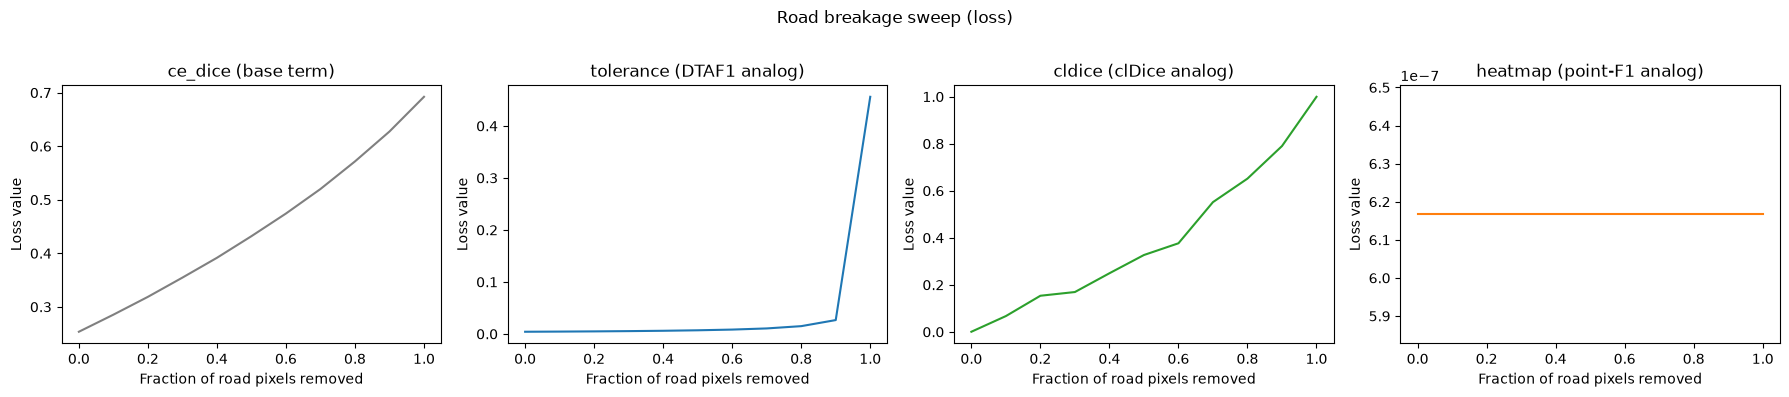

In [3]:
r_breakage = sweep_road_breakage_loss()
plot_small_multiples(r_breakage, 'fraction', 'Fraction of road pixels removed', 'Road breakage sweep (loss)')

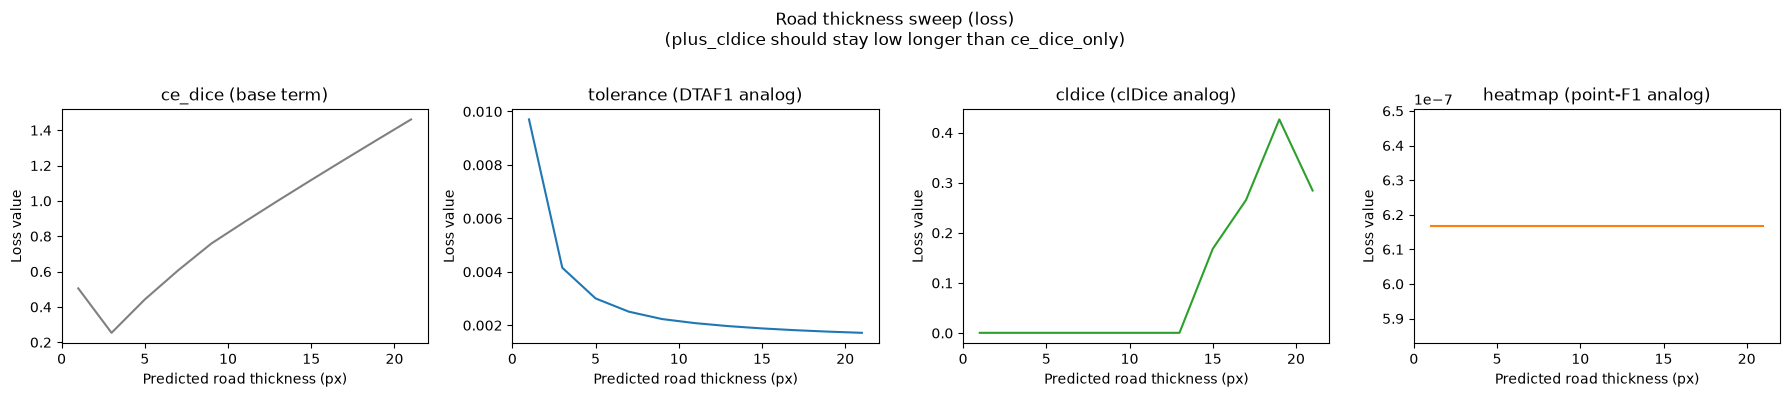

In [4]:
r_thickness = sweep_road_thickness_loss()
plot_small_multiples(r_thickness, 'thickness', 'Predicted road thickness (px)',
                      'Road thickness sweep (loss)\n(plus_cldice should stay low longer than ce_dice_only)')

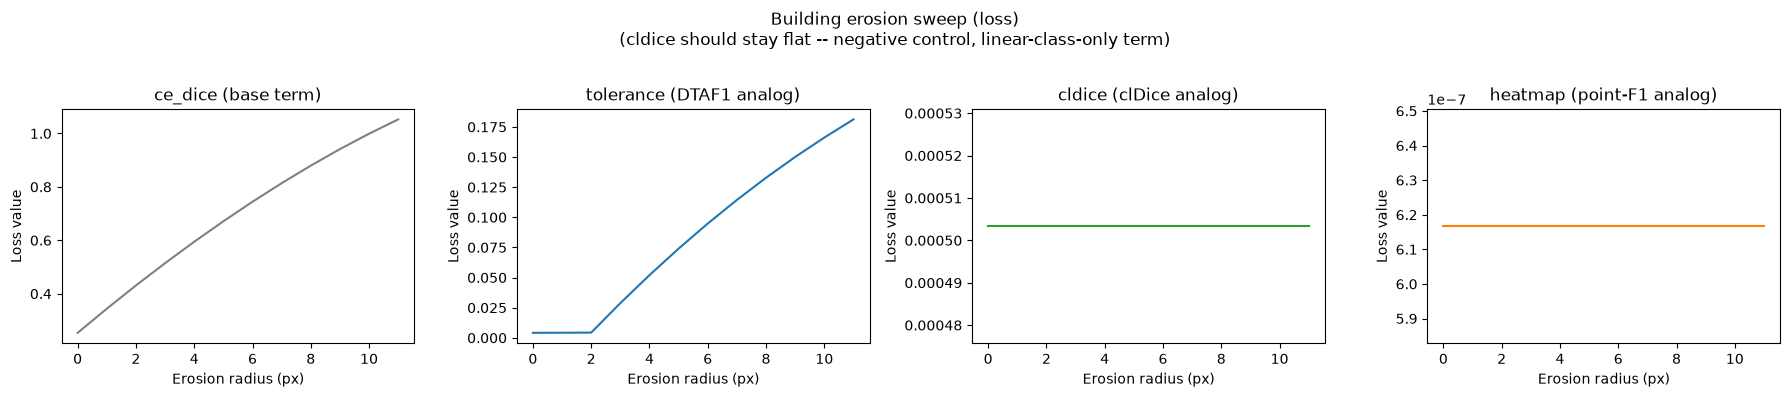

In [5]:
r_erosion = sweep_building_erosion_loss()
plot_small_multiples(r_erosion, 'erosion_px', 'Erosion radius (px)', 'Building erosion sweep (loss)\n(cldice should stay flat -- negative control, linear-class-only term)')

## 2. Point sweeps — heatmap ablation

`plus_heatmap` should be the term most distinctly shape-sensitive to point jitter/dropout/clutter.
`plus_tolerance` and `plus_cldice` should stay essentially flat throughout (negative control: neither
covers the point class — `ToleranceBandLoss` is configured over `linear_classes + polygon_classes`
only, `SoftClDiceLoss` over `linear_classes` only).

Note the heatmap term's absolute magnitude is much larger than the other three under point
perturbations (its CornerNet/CenterNet-style focal formulation is not a bounded [0,1] ratio the way
the tolerance/clDice terms are) — this is a real, documented property (see
`tests/test_loss_sensitivity.py::_logits_from_label`'s docstring), not a bug, and is exactly why
`PLEMMultiTaskLoss` exposes a `weights` dict for per-term rebalancing during real training.

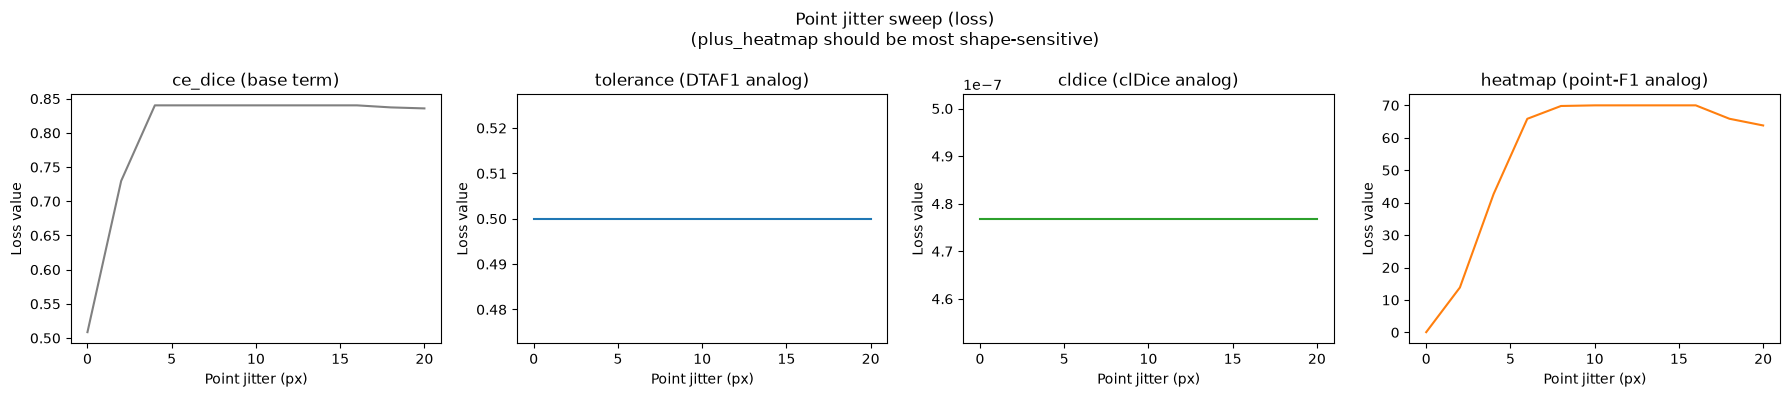

In [6]:
r_jitter = sweep_point_jitter_loss()
plot_small_multiples(r_jitter, 'offset', 'Point jitter (px)',
                      'Point jitter sweep (loss)\n(plus_heatmap should be most shape-sensitive)')

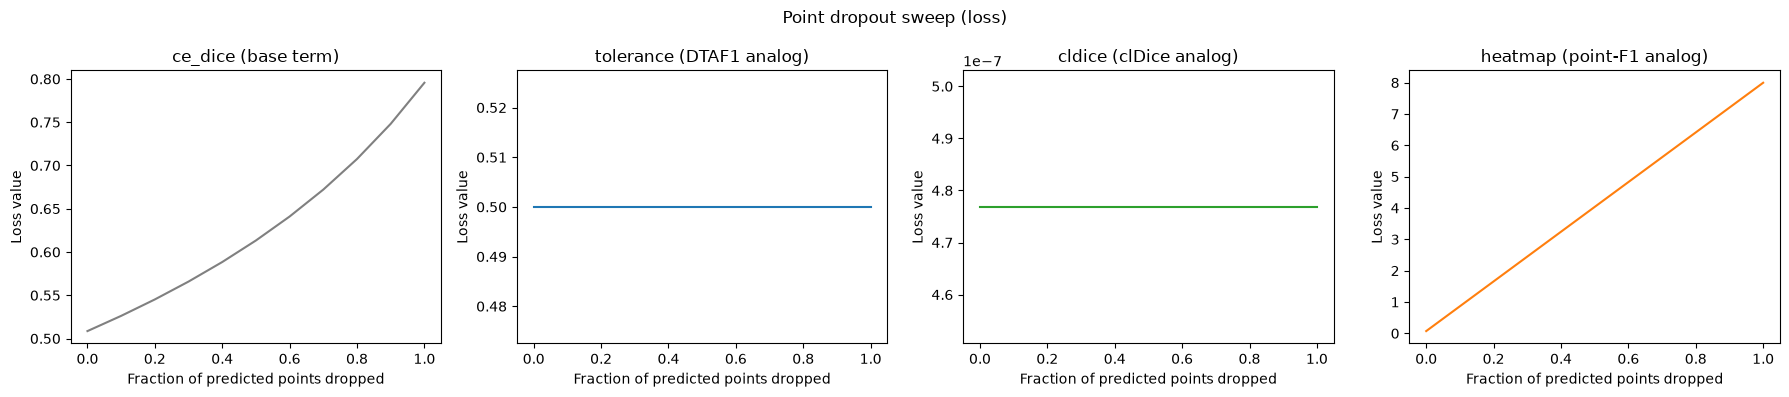

In [7]:
r_dropout = sweep_point_dropout_loss()
plot_small_multiples(r_dropout, 'fraction', 'Fraction of predicted points dropped', 'Point dropout sweep (loss)')

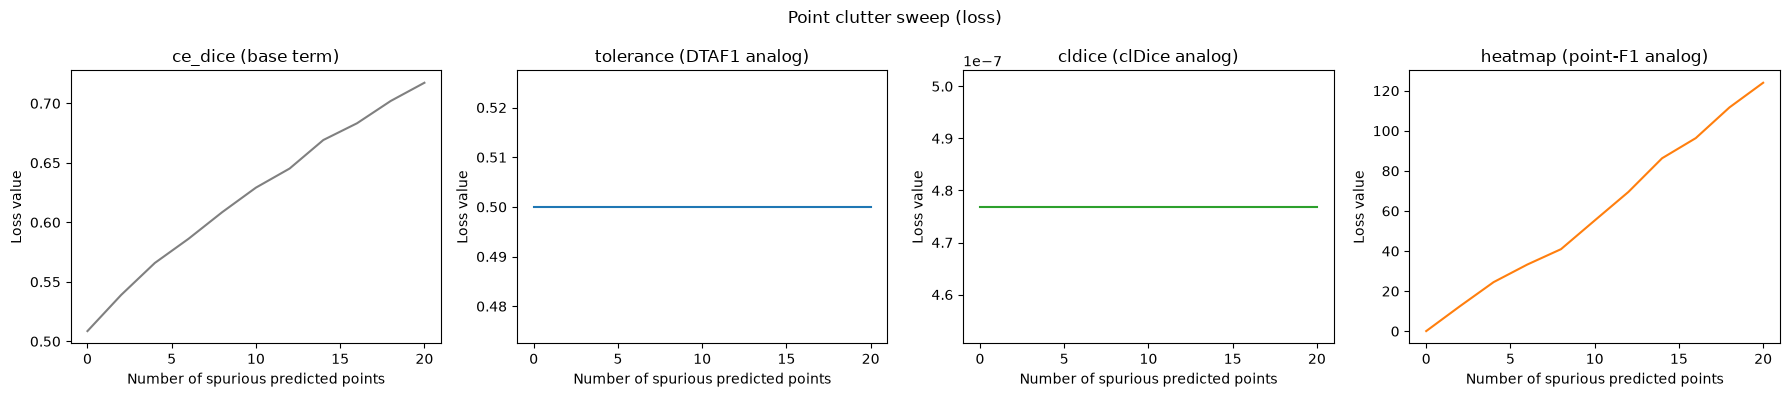

In [8]:
r_clutter = sweep_point_clutter_loss()
plot_small_multiples(r_clutter, 'n_extra', 'Number of spurious predicted points', 'Point clutter sweep (loss)')

## 3. Summary table

Cumulative ablation values (`ce_dice_only` / `+tolerance` / `+cldice` / `+heatmap` / `full`) at one
representative severity per sweep, colour-coded per column (columns differ in scale, so this uses
per-column — not global — normalization, unlike `metric_comparison.ipynb`'s fixed `vmin=0, vmax=1`,
since loss values are not bounded to [0, 1] the way eval-metric scores are).

In [9]:
def last_row(results):
    return {k: round(results[k][-1], 4) for k in CONFIG_KEYS}

rows = {
    'Road offset (24px)':        last_row(r_offset),
    'Road breakage (100%)':      last_row(r_breakage),
    'Road thickness (21px)':     last_row(r_thickness),
    'Building erosion (11px)':   last_row(r_erosion),
    'Point jitter (20px)':       last_row(r_jitter),
    'Point dropout (100%)':      last_row(r_dropout),
    'Point clutter (+20)':       last_row(r_clutter),
}

df = pd.DataFrame(rows).T
display(df.style.background_gradient(cmap='RdYlGn_r', axis=0)
               .set_caption('Loss value by ablation configuration at max severity per sweep (higher = worse)'))

,ce_dice_only,plus_tolerance,plus_cldice,plus_heatmap,full
Road offset (24px),0.883200,1.383500,1.883200,0.883200,2.383500
Road breakage (100%),0.692300,1.148300,1.691600,0.692300,2.147600
Road thickness (21px),1.461100,1.462800,1.745500,1.461100,1.747300
Building erosion (11px),1.052600,1.233800,1.053100,1.052600,1.234400
Point jitter (20px),0.835900,1.335900,0.835900,64.628700,65.128700
Point dropout (100%),0.795600,1.295600,0.795600,8.791300,9.291300
Point clutter (+20),0.717300,1.217300,0.717300,124.685000,125.185000


## 4. Key takeaways

| Sweep | Term expected to move most | Term expected to stay flat (negative control) |
|---|---|---|
| Road offset | `tolerance` (steps up past 10px), `cldice` (zero-tolerant, collapses fast) | `heatmap` |
| Road breakage | `cldice` (skeleton fragmentation) | `heatmap` |
| Road thickness | `cldice` (rises sharply past its `iters`-bounded width limit) | `heatmap`, `tolerance` stays low (width-tolerant by design) |
| Building erosion | `tolerance` (tight 2px building tolerance) | `cldice` (linear-class-only) |
| Point jitter / dropout / clutter | `heatmap` | `tolerance`, `cldice` (neither covers the point class) |

This confirms each new loss term is doing what its `metrics/` counterpart's own sensitivity story
says it should (see `notebooks/metric_comparison.ipynb`'s Section 3), now on the *training signal*
side rather than the eval-metric side. See `CLAUDE.md`'s `losses/` section for the full
per-module correspondence table and known limitations (soft-clDice's `iters`-bounded width
invariance, the heatmap term's differing magnitude scale, point-F1's Hungarian-vs-heatmap train/eval
mismatch).